# Fine-tuning (Transfer Learning)  

Adattare un modello pre-addestrato (ResNet18) a un nuovo dataset con poche epoche.
 

## 1) Import, device e dataset

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Trasformazioni: ridimensioniamo CIFAR-10 a 224x224 per ResNet18
tfm_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])  # standard ImageNet
])

tfm_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_full = datasets.CIFAR10("./data", train=True, download=True, transform=tfm_train)
test_full  = datasets.CIFAR10("./data", train=False, download=True, transform=tfm_test)

# Per uso didattico in aula, prendiamo solo un sottoinsieme (es: 5000 train, 2000 test)
train_idx = torch.randperm(len(train_full))[:5000]
test_idx  = torch.randperm(len(test_full))[:2000]

train_ds = Subset(train_full, train_idx)
test_ds  = Subset(test_full, test_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

print("Train size:", len(train_ds), "| Test size:", len(test_ds))

Device: cpu
Train size: 5000 | Test size: 2000


## 2) Caricamento del modello ResNet18 pre-addestrato e sostituzione dell'ultimo layer

In [2]:
# Carichiamo un modello ResNet18 pre-addestrato su ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print("Ultimo layer resnet:",resnet18.fc)

num_features = resnet18.fc.in_features

# CIFAR-10 ha 10 classi
num_classes = 10

# Sostituiamo l'ultimo fully-connected con uno nuovo
resnet18.fc = nn.Linear(num_features, num_classes)

# Congeliamo TUTTI i parametri tranne l'ultimo layer (fine-tuning "parziale")
for param in resnet18.parameters():
    param.requires_grad = False

for param in resnet18.fc.parameters():
    param.requires_grad = True

resnet18 = resnet18.to(device)
print("Ultimo layer Nuova rete:", resnet18.fc)

Ultimo layer resnet: Linear(in_features=512, out_features=1000, bias=True)
Ultimo layer Nuova rete: Linear(in_features=512, out_features=10, bias=True)


## 3) Funzioni di training e valutazione

In [ ]:
@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

- fine tuning anche del backbone

In [5]:
def train_finetune(model, train_loader, test_loader, epochs=3, lr_backbone = 1e-4, lr_fc = 1e-3):

    backbone_params = []
    for name, p in resnet18.named_parameters():
        if name.startswith("fc."): 
            continue
        if p.requires_grad:
            backbone_params.append(p)

    optimizer = torch.optim.Adam([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": resnet18.fc.parameters(), "lr": lr_fc},
    ])
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accs, test_accs = [], [], []

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        ep_loss = running_loss / total
        ep_train_acc = correct / total
        ep_test_acc = accuracy(model, test_loader)

        train_losses.append(ep_loss)
        train_accs.append(ep_train_acc)
        test_accs.append(ep_test_acc)

        print(f"Epoca {ep:02d} | loss {ep_loss:.4f} | train acc {ep_train_acc:.4f} | test acc {ep_test_acc:.4f}")

    # Plot
    xs = range(1, epochs+1)
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(xs, train_losses, marker='o')
    plt.title("Loss di training")
    plt.xlabel("Epoca"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(xs, train_accs, marker='o', label="Train")
    plt.plot(xs, test_accs,  marker='s', label="Test")
    plt.title("Accuracy")
    plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

    plt.tight_layout()
    plt.show()

- backbone freezato: training del solo layer fc

In [6]:
def train_transfer_learning(model, train_loader, test_loader, epochs=3, lr=1e-3):
    # NOTA: ottimizzatore solo sull'ultimo layer (fc)
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accs, test_accs = [], [], []

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        ep_loss = running_loss / total
        ep_train_acc = correct / total
        ep_test_acc = accuracy(model, test_loader)

        train_losses.append(ep_loss)
        train_accs.append(ep_train_acc)
        test_accs.append(ep_test_acc)

        print(f"Epoca {ep:02d} | loss {ep_loss:.4f} | train acc {ep_train_acc:.4f} | test acc {ep_test_acc:.4f}")

    # Plot
    xs = range(1, epochs+1)
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(xs, train_losses, marker='o')
    plt.title("Loss di training")
    plt.xlabel("Epoca"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(xs, train_accs, marker='o', label="Train")
    plt.plot(xs, test_accs,  marker='s', label="Test")
    plt.title("Accuracy")
    plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

    plt.tight_layout()
    plt.show()

## 4) Avvio del fine-tuning

Epoca 01 | loss 0.7295 | train acc 0.7684 | test acc 0.7375
Epoca 02 | loss 0.6727 | train acc 0.7848 | test acc 0.7345
Epoca 03 | loss 0.6554 | train acc 0.7840 | test acc 0.7500


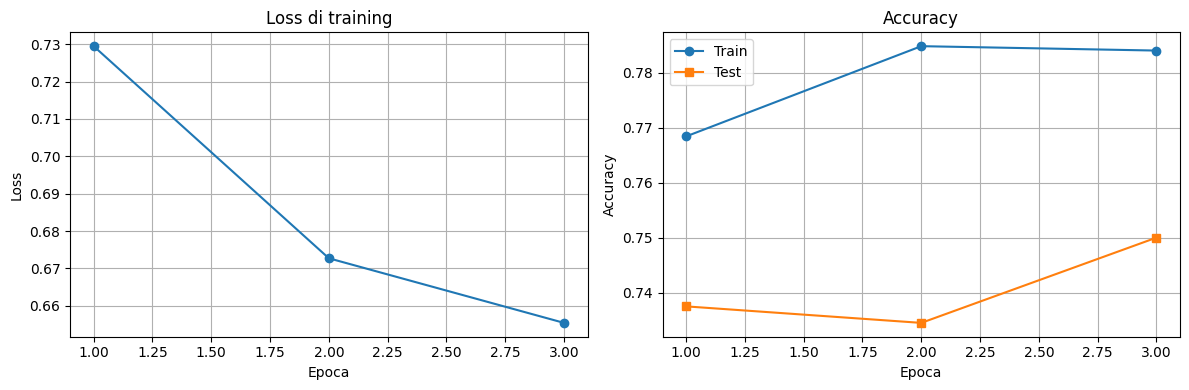

In [7]:
train_finetune(resnet18, train_loader, test_loader, epochs=3)

Epoca 01 | loss 0.6338 | train acc 0.7876 | test acc 0.7495
Epoca 02 | loss 0.5871 | train acc 0.8128 | test acc 0.7560
Epoca 03 | loss 0.5809 | train acc 0.8048 | test acc 0.7590


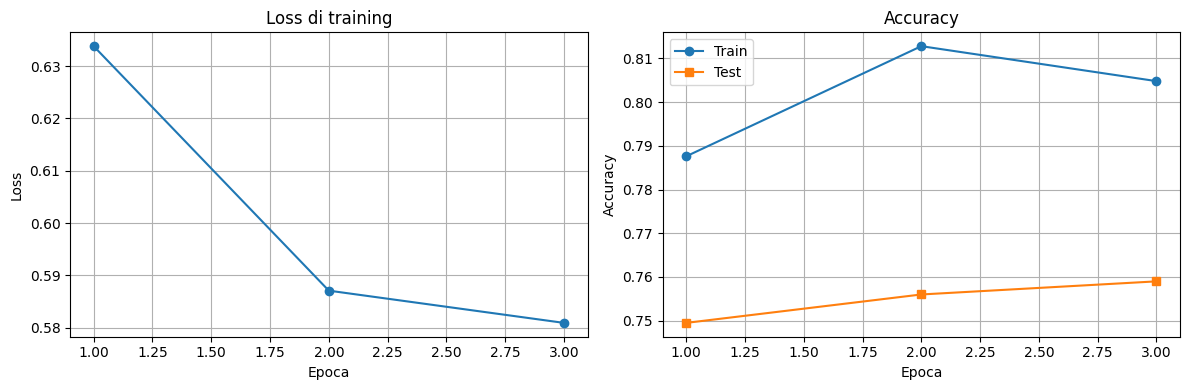

In [8]:
train_transfer_learning(resnet18, train_loader, test_loader, epochs=3)